# Payment Transaction Anomaly Classification

## Learn Depth Academy LLP – Track 1 Final Capstone – Problem 26

### Project Objective

The objective of this project is to classify payment transactions into
two categories:

- Routine / Legitimate Transaction
- Anomalous / Fraudulent Transaction

This notebook presents the complete machine learning workflow, including:

1. Dataset loading
2. Data quality investigation
3. Exploratory Data Analysis
4. Data preprocessing
5. Train-test splitting
6. Feature scaling
7. Logistic Regression
8. Decision Tree
9. Model evaluation
10. Confusion Matrix
11. Error analysis
12. Final model selection
13. Model saving

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

import joblib

## 1. Load Dataset

The project uses the Credit Card Fraud Detection dataset obtained from Kaggle.

The dataset contains transaction time, anonymized numerical features
(V1 to V28), transaction amount, and the target class.

In [10]:
# Load the dataset

data_path = "../data/archive (1)/creditcard.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Basic Dataset Information

The dataset structure, data types, number of records, and statistical
summary are examined before preprocessing.

In [12]:
print("Number of rows and columns:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

Number of rows and columns:
(284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null 

In [13]:
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [14]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nTotal missing values:")
print(df.isnull().sum().sum())

Missing values in each column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Total missing values:
0


In [15]:
# Check infinite values

numeric_columns = df.select_dtypes(include=np.number).columns

infinite_values = np.isinf(df[numeric_columns]).sum().sum()

print("Total infinite values:", infinite_values)

Total infinite values: 0


In [16]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 1081


In [17]:
# Check data types

print("Data types of columns:")
print(df.dtypes)

Data types of columns:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [18]:
# Check missing target values

print("Missing values in target column (Class):")
print(df["Class"].isnull().sum())

Missing values in target column (Class):
0


In [19]:
# Remove rows only if the target value is missing

if df["Class"].isnull().sum() > 0:
    df = df.dropna(subset=["Class"]).copy()
    print("Rows with missing target values were removed.")
else:
    print("No missing target values found.")

print("Current dataset shape:", df.shape)

No missing target values found.
Current dataset shape: (284807, 31)


## 4. Class Distribution

The target variable is examined to understand the balance between
legitimate and fraudulent transactions.

In [20]:
# Count of each class

class_counts = df["Class"].value_counts()

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(df["Class"].value_counts(normalize=True) * 100)

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


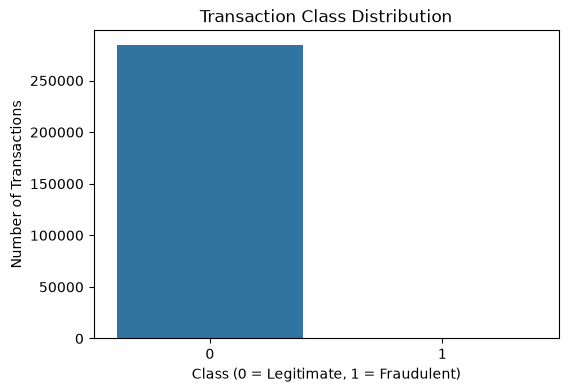

In [21]:
# Visualize class distribution

plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Number of Transactions")

plt.show()

## 5. Transaction Amount Analysis

The transaction amount is analyzed to understand its distribution
and differences between legitimate and fraudulent transactions.

In [22]:
# Count of each class

class_counts = df["Class"].value_counts()

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(df["Class"].value_counts(normalize=True) * 100)

Class counts:
Class
0    284315
1       492
Name: count, dtype: int64

Class percentages:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


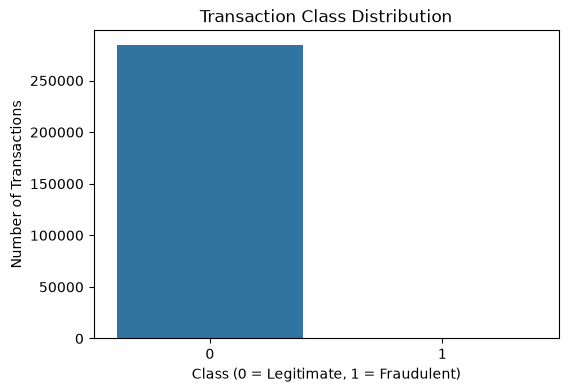

In [23]:
# Visualize class distribution

plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Number of Transactions")

plt.show()

## 5. Transaction Amount Analysis

The transaction amount is analyzed to understand its distribution
and differences between legitimate and fraudulent transactions.

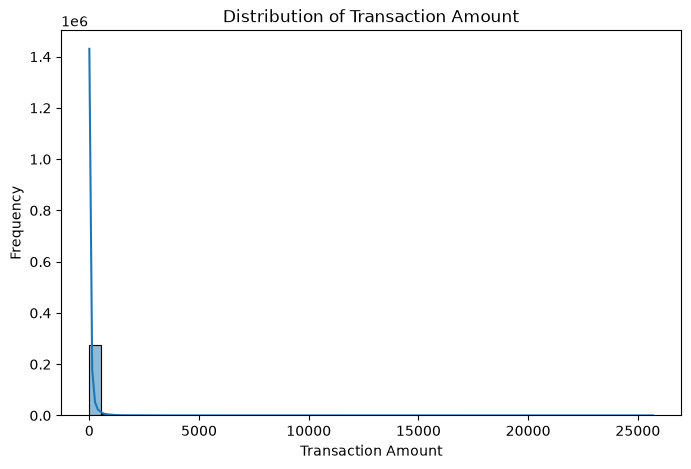

In [24]:
# Distribution of transaction amount

plt.figure(figsize=(8, 5))

sns.histplot(df["Amount"], bins=50, kde=True)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

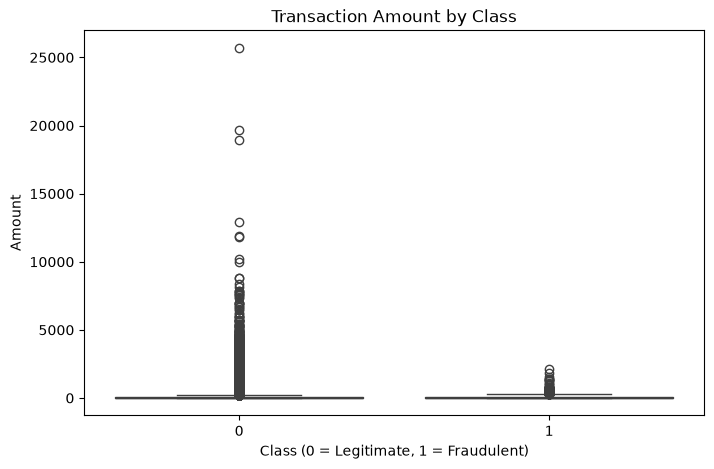

In [25]:
# Transaction amount by class

plt.figure(figsize=(8, 5))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Amount")

plt.show()

## 6. Transaction Time Analysis

The transaction time is analyzed to identify differences in
transaction timing between legitimate and fraudulent records.

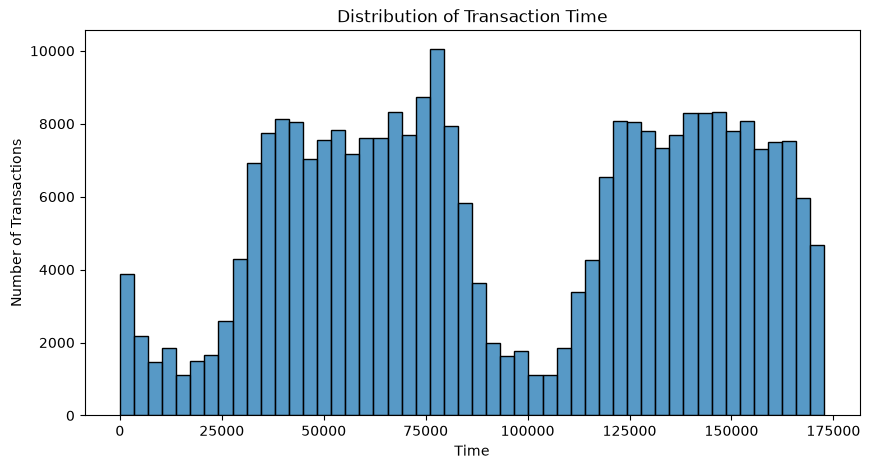

In [26]:
# Distribution of transaction time

plt.figure(figsize=(10, 5))

sns.histplot(df["Time"], bins=50)

plt.title("Distribution of Transaction Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

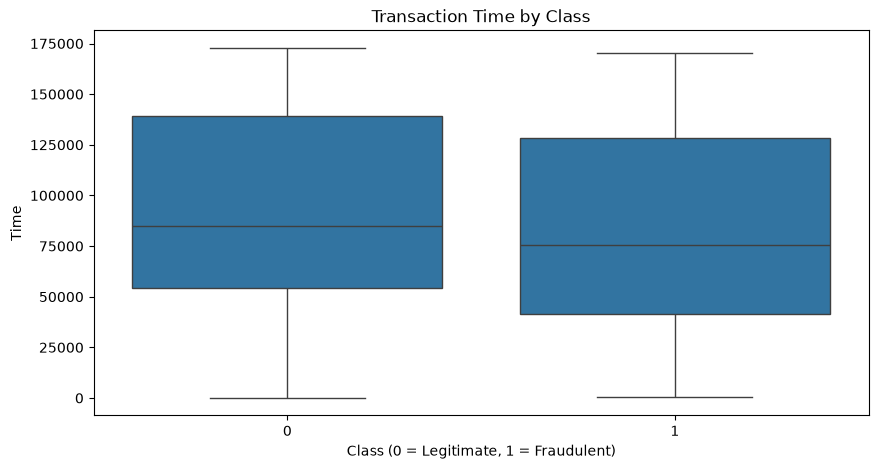

In [27]:
# Transaction time by class

plt.figure(figsize=(10, 5))

sns.boxplot(x="Class", y="Time", data=df)

plt.title("Transaction Time by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraudulent)")
plt.ylabel("Time")

plt.show()

## 7. Feature Correlation Analysis

Correlation analysis is performed to understand relationships
between numerical features and the target variable

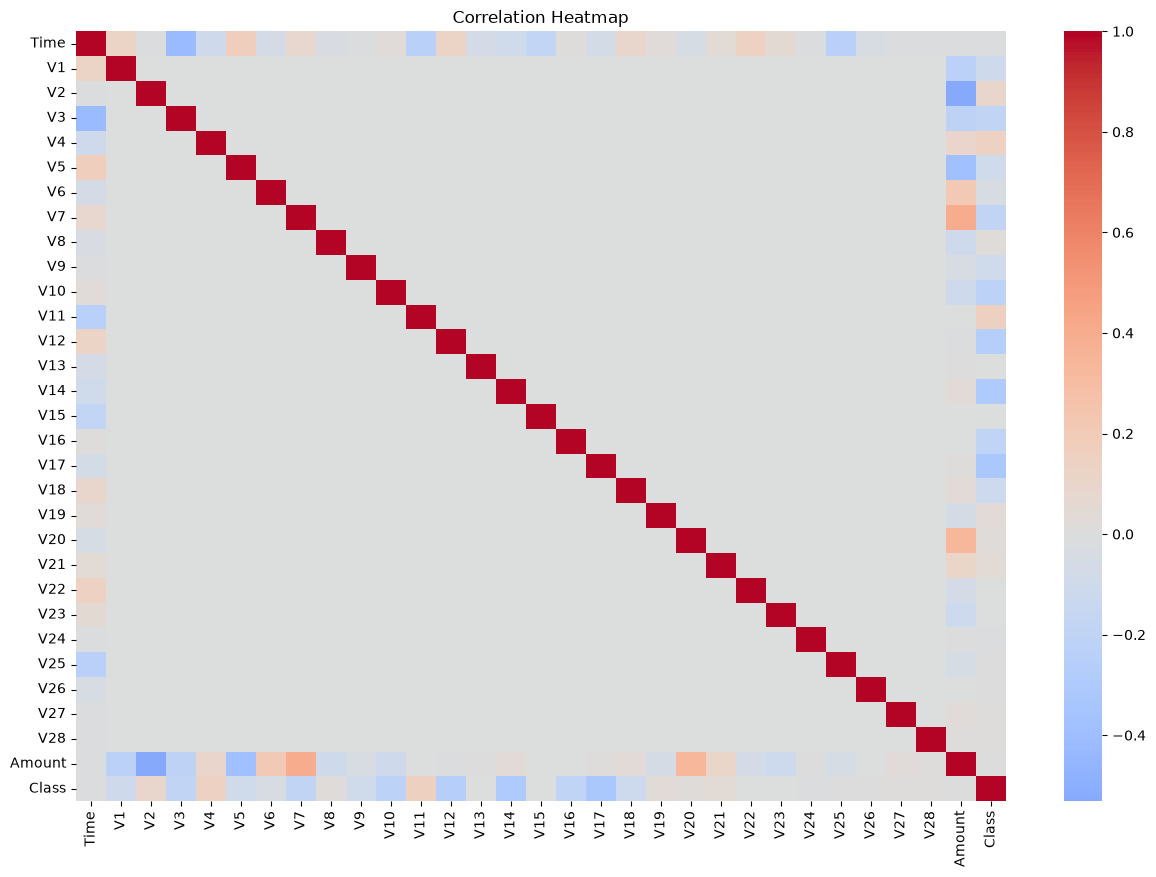

In [28]:
# Correlation heatmap

plt.figure(figsize=(15, 10))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [29]:
# Correlation of features with the target

class_correlation = df.corr()["Class"].sort_values(ascending=False)

print("Correlation with Class:")
print(class_correlation
      )

Correlation with Class:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


## 8. Outlier Investigation

Outliers are investigated because unusual transaction values may represent
legitimate unusual behavior or fraudulent activity.

Outliers are therefore not automatically removed, since removing extreme
values could also remove important anomalous transactions.

In [30]:
# Check outliers in transaction amount using IQR

Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

amount_outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print("Number of Amount outliers:", len(amount_outliers))
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Number of Amount outliers: 31904
Lower bound: -101.7475
Upper bound: 184.5125


## 9. Data Leakage Check

The target variable `Class` is excluded from the input features.
The train-test split is performed before fitting the scaler so that
information from the test set is not used during training.

The dataset does not contain a raw transaction ID column that is used
as a predictive feature.

In [32]:
# Check columns

print("Dataset columns:")
print(df.columns.tolist())

print("\nTarget column:", "Class")

Dataset columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Target column: Class


## 10. Feature and Target Preparation

The target column `Class` is separated from the input features.

Class:
- 0 = Legitimate
- 1 = Fraudulent

In [33]:
# Separate features and target

X = df.drop("Class", axis=1)
y = df["Class"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (284807, 30)
Target shape: (284807,)

Features:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## 11. Train-Test Split

The dataset is divided into training and testing sets.

Stratification is used to preserve the proportion of legitimate
and fraudulent transactions in both sets.

In [34]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training feature shape: (227845, 30)
Testing feature shape: (56962, 30)

Training target distribution:
Class
0    227451
1       394
Name: count, dtype: int64

Testing target distribution:
Class
0    56864
1       98
Name: count, dtype: int64


## 12. Feature Scaling

StandardScaler is used to standardize the numerical features.

The scaler is fitted only on the training data and then applied
to both training and testing data to avoid data leakage.

In [35]:
# Standardize the features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Feature scaling completed.
Training data shape: (227845, 30)
Testing data shape: (56962, 30)


## 13. Model 1 – Logistic Regression

Logistic Regression is used as a foundational classification model
for comparison.

In [36]:
# Train Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [37]:
# Train Decision Tree

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

decision_tree_model.fit(
    X_train_scaled,
    y_train
)

y_pred_tree = decision_tree_model.predict(
    X_test_scaled
)

print("Decision Tree training completed.")

Decision Tree training completed.


In [ ]:
import joblib
import os

# Create models folder
os.makedirs("../models", exist_ok=True)


# Save Decision Tree model
joblib.dump(
    decision_tree_model,
    "../models/decision_tree_model.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

# Save feature names
joblib.dump(
    list(X.columns),
    "../models/feature_names.pkl"
)

print("All model files saved successfully.")

All model files saved successfully.


In [38]:
# Logistic Regression metrics

logistic_accuracy = accuracy_score(y_test, y_pred_logistic)
logistic_precision = precision_score(y_test, y_pred_logistic, zero_division=0)
logistic_recall = recall_score(y_test, y_pred_logistic, zero_division=0)
logistic_f1 = f1_score(y_test, y_pred_logistic, zero_division=0)

logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("Logistic Regression Results")
print("---------------------------")
print(f"Accuracy  : {logistic_accuracy:.4f}")
print(f"Precision : {logistic_precision:.4f}")
print(f"Recall    : {logistic_recall:.4f}")
print(f"F1 Score  : {logistic_f1:.4f}")
print(f"ROC-AUC   : {logistic_roc_auc:.4f}")


Logistic Regression Results
---------------------------
Accuracy  : 0.9991
Precision : 0.8267
Recall    : 0.6327
F1 Score  : 0.7168
ROC-AUC   : 0.9605


In [39]:
# Classification report

print("Logistic Regression Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_logistic,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)

Logistic Regression Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



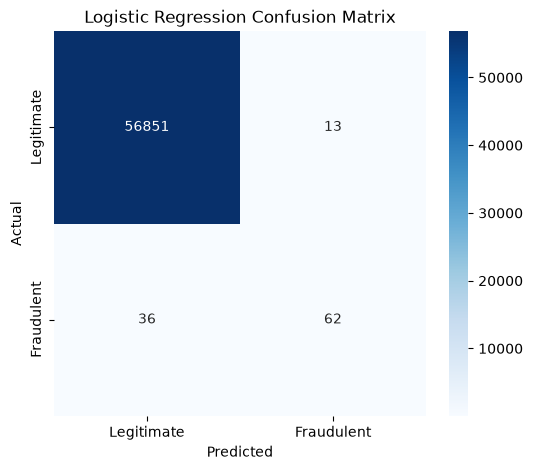

In [40]:
# Confusion matrix

logistic_cm = confusion_matrix(
    y_test,
    y_pred_logistic
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 14. Model 2 – Decision Tree

A Decision Tree classifier is trained as another foundational
classification model.

A maximum depth is used to control model complexity.

In [41]:
# Train Decision Tree

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

decision_tree_model.fit(
    X_train_scaled,
    y_train
)

y_pred_tree = decision_tree_model.predict(X_test_scaled)

print("Decision Tree training completed.")

Decision Tree training completed.


In [42]:
# Decision Tree metrics

tree_accuracy = accuracy_score(y_test, y_pred_tree)
tree_precision = precision_score(y_test, y_pred_tree, zero_division=0)
tree_recall = recall_score(y_test, y_pred_tree, zero_division=0)
tree_f1 = f1_score(y_test, y_pred_tree, zero_division=0)

tree_probabilities = decision_tree_model.predict_proba(X_test_scaled)[:, 1]

tree_roc_auc = roc_auc_score(
    y_test,
    tree_probabilities
)

print("Decision Tree Results")
print("---------------------")
print(f"Accuracy  : {tree_accuracy:.4f}")
print(f"Precision : {tree_precision:.4f}")
print(f"Recall    : {tree_recall:.4f}")
print(f"F1 Score  : {tree_f1:.4f}")
print(f"ROC-AUC   : {tree_roc_auc:.4f}")

Decision Tree Results
---------------------
Accuracy  : 0.9994
Precision : 0.8902
Recall    : 0.7449
F1 Score  : 0.8111
ROC-AUC   : 0.8095


In [43]:
# Classification report

print("Decision Tree Classification Report:")
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Legitimate", "Fraudulent"],
        zero_division=0
    )
)

Decision Tree Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
  Fraudulent       0.89      0.74      0.81        98

    accuracy                           1.00     56962
   macro avg       0.94      0.87      0.91     56962
weighted avg       1.00      1.00      1.00     56962



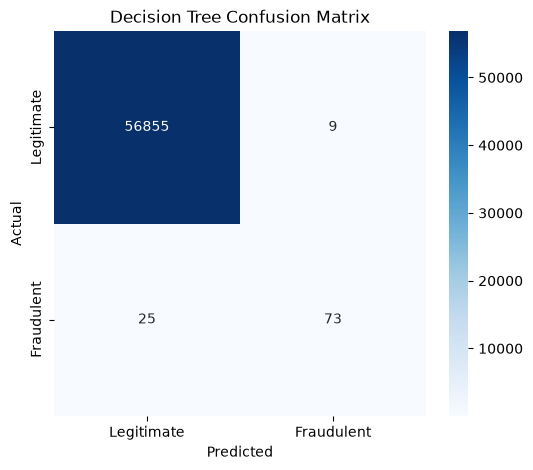

In [44]:

tree_cm = confusion_matrix(
    y_test,
    y_pred_tree
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraudulent"],
    yticklabels=["Legitimate", "Fraudulent"]
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 15. Model Comparison

The performance of Logistic Regression and Decision Tree is compared
using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [45]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        logistic_accuracy,
        tree_accuracy
    ],
    "Precision": [
        logistic_precision,
        tree_precision
    ],
    "Recall": [
        logistic_recall,
        tree_recall
    ],
    "F1 Score": [
        logistic_f1,
        tree_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        tree_roc_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.999140,0.826667,0.632653,0.716763,0.960549
1,Decision Tree,0.999403,0.890244,0.744898,0.811111,0.809468


## 16. Error Analysis

Classification errors are analyzed using the confusion matrix.

Special attention is given to:
- False Positives: legitimate transactions incorrectly classified as fraudulent.
- False Negatives: fraudulent transactions incorrectly classified as legitimate.

In [46]:
# Error analysis for Decision Tree

false_positives = (
    (y_test == 0) &
    (y_pred_tree == 1)
).sum()

false_negatives = (
    (y_test == 1) &
    (y_pred_tree == 0)
).sum()

true_positives = (
    (y_test == 1) &
    (y_pred_tree == 1)
).sum()

true_negatives = (
    (y_test == 0) &
    (y_pred_tree == 0)
).sum()

print("Decision Tree Error Analysis")
print("-----------------------------")
print("True Negatives :", true_negatives)
print("False Positives:", false_positives)
print("False Negatives:", false_negatives)
print("True Positives :", true_positives)

Decision Tree Error Analysis
-----------------------------
True Negatives : 56855
False Positives: 9
False Negatives: 25
True Positives : 73


In [47]:

error_analysis = X_test.copy()

error_analysis["Actual_Class"] = y_test
error_analysis["Predicted_Class"] = y_pred_tree

misclassified = error_analysis[
    error_analysis["Actual_Class"] !=
    error_analysis["Predicted_Class"]
]

print("Number of misclassified transactions:", len(misclassified))

misclassified.head(10)

Number of misclassified transactions: 34


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Actual_Class,Predicted_Class
190263,128759.0,-1.272117,1.827615,-3.810610,0.583759,-0.641242,-1.389043,-1.954054,1.173920,-2.053191,...,0.858775,0.083079,0.741676,-0.173234,0.534870,0.183562,0.020316,0.76,0,1
62346,50236.0,-18.536782,-18.661904,-1.032544,6.518726,9.900486,-5.748890,0.076492,-2.351598,1.058671,...,2.670060,12.557883,0.343397,4.881207,1.065160,5.865844,-3.618662,68.18,0,1
9643,14446.0,0.526768,0.314305,-0.497534,0.959570,-1.625545,-0.367521,-2.374770,0.556905,0.829738,...,0.205001,-0.034629,-0.010887,0.146244,1.075946,0.301438,0.171752,39.00,0,1
14170,25198.0,-15.903635,10.393917,-19.133602,6.185969,-12.538021,-4.027030,-13.897827,10.662252,-2.844954,...,-1.280137,-0.601295,0.040404,0.995502,-0.273743,1.688136,0.527831,99.99,1,0
222133,142840.0,-3.613850,-0.922136,-4.749887,3.373001,-0.545207,-1.171301,-4.172315,1.517016,-1.775833,...,0.893065,1.034907,0.097671,-1.345551,-0.788329,1.055442,0.099971,144.80,1,0
14197,25231.0,-16.598665,10.541751,-19.818982,6.017295,-13.025901,-4.128779,-14.118865,11.161144,-4.099551,...,-1.151606,-0.680052,0.108176,1.066878,-0.233720,1.707521,0.511423,99.99,1,0
30100,35771.0,-3.218952,2.708535,-3.263042,1.361866,-1.645776,-1.852982,-3.069958,-1.796876,-0.213356,...,-0.890421,-0.325814,0.123040,-0.093014,0.232106,-0.310519,-0.745295,60.60,1,0
153398,98904.0,-2.690251,1.465266,-0.691844,4.322855,-1.086880,0.063585,-2.966872,-0.059646,-0.090827,...,0.259112,0.610188,-0.119366,0.028077,-0.044074,0.005614,0.557189,0.00,0,1
18809,29785.0,0.923764,0.344048,-2.880004,1.721680,-3.019565,-0.639736,-3.801325,1.299096,0.864065,...,1.481271,0.725266,0.176960,-1.815638,-0.536517,0.489035,-0.049729,30.30,1,0
50537,44532.0,-0.234922,0.355413,1.972183,-1.255593,-0.681387,-0.665732,0.059110,-0.003153,1.122451,...,0.912107,-0.286338,0.451208,0.188315,-0.531846,0.123185,0.039581,1.00,1,0


## 17. Final Model Selection

Two foundational classification models were evaluated:
Logistic Regression and Decision Tree.

The Decision Tree achieved higher recall and F1-score on the test set
and was selected as the final model for this educational prototype.

Logistic Regression achieved a higher ROC-AUC score. Therefore,
ROC-AUC is also considered when interpreting the results.

The Decision Tree will be used for the Streamlit prototype.

In [38]:
# Feature importance from Decision Tree

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": decision_tree_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
17,V17,0.612190
14,V14,0.108322
12,V12,0.060271
10,V10,0.057917
26,V26,0.026683
27,V27,0.020562
4,V4,0.016975
20,V20,0.012996
16,V16,0.012821
21,V21,0.012641


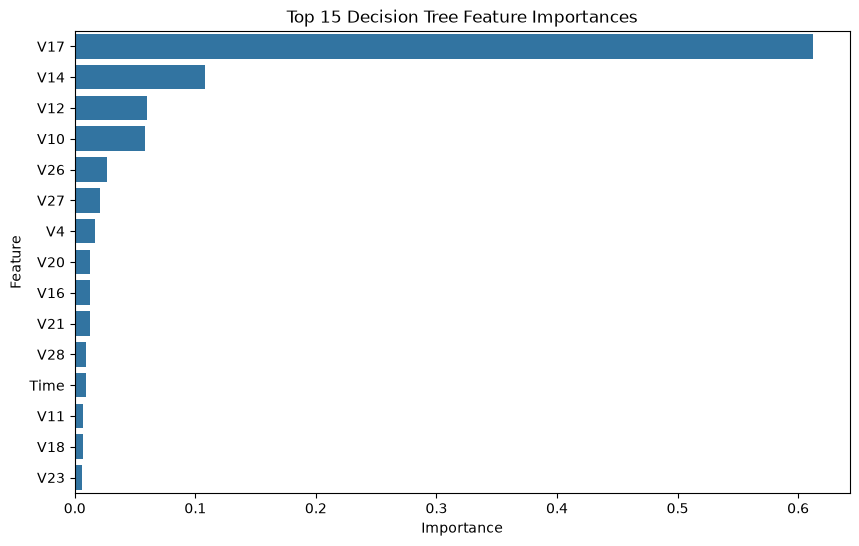

In [39]:
# Plot top 15 important features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()



## 18. Save Trained Model

The final Decision Tree model, scaler, and feature names are saved
for use in the Streamlit application.

In [ ]:
# Load the saved model and test it

loaded_model = joblib.load("../decision_tree_model.pkl")
loaded_scaler = joblib.load("../scaler.pkl")
loaded_features = joblib.load("../feature_names.pkl")

# Use the first test transaction
sample_transaction = X_test.iloc[[0]]

sample_scaled = loaded_scaler.transform(
    sample_transaction[loaded_features]
)

sample_prediction = loaded_model.predict(sample_scaled)[0]

print("Sample transaction prediction:", sample_prediction)

if sample_prediction == 1:
    print("Prediction: Anomalous / Fraudulent")
else:
    print("Prediction: Routine / Legitimate")

In [49]:
import joblib

# Load the saved files
loaded_model = joblib.load("../models/decision_tree_model.pkl")
loaded_scaler = joblib.load("../models/scaler.pkl")
loaded_features = joblib.load("../models/feature_names.pkl")

# Take one transaction from the test data
sample_transaction = X_test.iloc[[0]]

# Scale the transaction
sample_scaled = loaded_scaler.transform(
    sample_transaction[loaded_features]
)

# Make prediction
sample_prediction = loaded_model.predict(sample_scaled)[0]

print("Sample transaction prediction:", sample_prediction)

if sample_prediction == 1:
    print("Prediction: Anomalous / Fraudulent")
else:
    print("Prediction: Routine / Legitimate")

Sample transaction prediction: 0
Prediction: Routine / Legitimate


## 19. Project Conclusion

This project developed an end-to-end machine learning solution for
payment transaction anomaly classification.

The workflow included:
1. Dataset loading and understanding
2. Data quality investigation
3. Exploratory Data Analysis
4. Data preprocessing
5. Train-test splitting
6. Feature scaling
7. Logistic Regression
8. Decision Tree
9. Model evaluation
10. Confusion matrix analysis
11. Error analysis
12. Final model selection
13. Model saving for deployment

The Decision Tree was selected as the final model for the educational
Streamlit prototype based on its test-set performance, particularly
its recall and F1-score.

The dataset contains anonymized features V1 to V28 along with Time,
Amount, and Class. Therefore, these anonymized features should not be
interpreted as direct merchant, category, or account-history fields.

The model is intended as an educational prototype and should not be
treated as a production financial fraud detection system.